In [15]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [36]:
# ---- 0. LOAD DATA ----
num = pd.read_csv("rmpCapstoneNum.csv", header=None)
qual = pd.read_csv("rmpCapstoneQual.csv", header=None)
tags = pd.read_csv("rmpCapstoneTags.csv", header=None)

num.columns = [
    "avg_rating",
    "avg_difficulty",
    "n_ratings",
    "pepper",
    "would_take_again",
    "n_online_ratings",
    "male",
    "female"
]

qual.columns = ["major", "university", "state"]

tag_names = [
    "tough_grader", "good_feedback", "respected", "lots_to_read",
    "participation_matters", "dont_skip_class", "lots_of_homework",
    "inspirational", "pop_quizzes", "accessible", "so_many_papers",
    "clear_grading", "hilarious", "test_heavy", "graded_by_few_things",
    "amazing_lectures", "caring", "extra_credit", "group_projects",
    "lecture_heavy"
]

tags.columns = tag_names

df = pd.concat([num, qual, tags], axis=1)

# ---- BASIC CLEANING ----

# Remove missing key values
df_clean = df.dropna(subset=["avg_rating", "avg_difficulty", "n_ratings"])

# Filter by minimum number of ratings
MIN_RATINGS = 5
df_clean = df_clean[df_clean["n_ratings"] >= MIN_RATINGS]

# Keep only known-gender rows (male = 1 OR female = 1)
df_known_gender = df_clean[(df_clean["male"] == 1) | (df_clean["female"] == 1)].copy()

In [38]:
df

,avg_rating,avg_difficulty,n_ratings,pepper,would_take_again,n_online_ratings,male,female,major,university,...,so_many_papers,clear_grading,hilarious,test_heavy,graded_by_few_things,amazing_lectures,caring,extra_credit,group_projects,lecture_heavy
0,5.0,1.5,2.0,0.0,NaN,0.0,0,1,Criminal Justice,George Mason University,...,0,0,0,0,0,0,0,0,0,1
1,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,3.2,3.0,4.0,0.0,NaN,0.0,1,0,English,Alabama State University,...,0,0,0,0,0,0,0,0,0,0
3,3.6,3.5,10.0,1.0,NaN,0.0,0,0,English,University of Kentucky,...,0,2,1,0,0,0,0,0,1,0
4,1.0,5.0,1.0,0.0,NaN,0.0,0,0,English,Keiser University,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89888,2.5,2.5,2.0,0.0,NaN,0.0,0,0,Computer Science,Texas Tech University,...,0,0,0,0,0,0,0,0,0,0
89889,4.5,2.0,2.0,0.0,NaN,0.0,1,0,Theater,University of Winnipeg,...,0,1,0,0,0,0,1,0,0,0
89890,5.0,1.7,6.0,1.0,100.0,2.0,1,0,Criminal Justice,Salt Lake Community College,...,0,0,4,0,0,1,0,0,0,0
89891,3.6,1.8,5.0,0.0,NaN,0.0,0,0,French,University of Ottawa,...,0,4,0,0,0,0,2,0,0,3


**Question 1**


Activists have asserted that there is a strong gender bias in student evaluations of professors, with
male professors enjoying a boost in rating from this bias. While this has been celebrated by ideologues,
skeptics have pointed out that this research is of technically poor quality, either due to a low sample
size – as small as n = 1 (Mitchell & Martin, 2018), failure to control for confounders such as teaching
experience (Centra & Gaubatz, 2000) or obvious p-hacking (MacNell et al., 2015). We would like you to
answer the question whether there is evidence of a pro-male gender bias in this dataset.
Hint: A significance test is probably required.

Q1: Is there evidence of a pro-male gender bias in average rating?

Number of male profs:   10791
Number of female profs: 9183
Mean rating (male):     3.914
Mean rating (female):   3.860
Difference (male - female): 0.054
Welch t-statistic: 4.101
Two-sided p-value: 4.12e-05
One-sided p-value for H1: male > female: 2.06e-05

Conclusion (alpha = 0.005):
  There IS statistically significant evidence of a pro-male gender bias in average ratings.


Text(0, 0.5, 'Average Rating')

<Figure size 640x480 with 0 Axes>

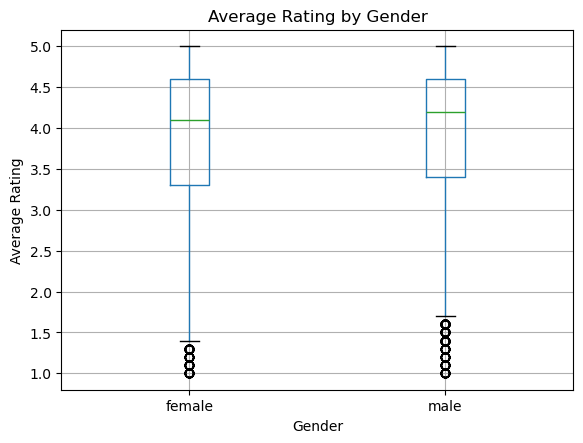

In [32]:
# ----- Q1: Pro-male gender bias in average rating -----

# Split into male / female groups
male_rating   = df_known_gender[df_known_gender["male"] == 1]["avg_rating"]
female_rating = df_known_gender[df_known_gender["female"] == 1]["avg_rating"]

male_mean   = male_rating.mean()
female_mean = female_rating.mean()
male_sd     = male_rating.std(ddof=1)
female_sd   = female_rating.std(ddof=1)
male_n      = male_rating.size
female_n    = female_rating.size

# Welch t-test (two-sided)
t_stat, p_two = stats.ttest_ind(
    male_rating,
    female_rating,
    equal_var=False,
    nan_policy="omit"
)

# One-sided p-value for directional hypothesis H1: male_mean > female_mean
if male_mean > female_mean:
    p_one = p_two / 2
else:
    p_one = 1 - p_two / 2

diff_mean = male_mean - female_mean   # pro-male if > 0
alpha = 0.005

# Print results
print("Q1: Is there evidence of a pro-male gender bias in average rating?\n")
print(f"Number of male profs:   {male_n}")
print(f"Number of female profs: {female_n}")
print(f"Mean rating (male):     {male_mean:.3f}")
print(f"Mean rating (female):   {female_mean:.3f}")
print(f"Difference (male - female): {diff_mean:.3f}")
print(f"Welch t-statistic: {t_stat:.3f}")
print(f"Two-sided p-value: {p_two:.3g}")
print(f"One-sided p-value for H1: male > female: {p_one:.3g}\n")

if (diff_mean > 0) and (p_one < alpha):
    print(f"Conclusion (alpha = {alpha}):")
    print("  There IS statistically significant evidence of a pro-male "
          "gender bias in average ratings.")
else:
    print(f"Conclusion (alpha = {alpha}):")
    if diff_mean > 0:
        print("  Male professors have slightly higher mean ratings, "
              "but this difference is NOT statistically significant "
              "at the chosen alpha.")
    else:
        print("  There is no evidence of a pro-male bias; if anything, "
              "female professors are rated as highly or higher.")

# ---- Boxplot figure for report ----
plot_q1 = pd.DataFrame({
    "avg_rating": pd.concat([male_rating, female_rating], ignore_index=True),
    "gender": ["male"] * male_n + ["female"] * female_n
})

plt.figure()
plot_q1.boxplot(column="avg_rating", by="gender")
plt.title("Average Rating by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Average Rating")

**Question 2**

Is there a gender difference in the spread (variance/dispersion) of the ratings distribution? Again, it
is advisable to consider the statistical significance of any observed gender differences in this spread.

Q2: Is there a gender difference in the spread of the ratings distribution?

Number of male profs:   10791
Number of female profs: 9183
Variance (male):        0.8284
Variance (female):      0.9001
Std dev (male):         0.9102
Std dev (female):       0.9488
Variance ratio (male / female): 0.920
Levene test statistic:  22.709
Levene p-value:         1.9e-06

Conclusion (alpha = 0.005):
  There IS a statistically significant gender difference in the spread (variance) of average ratings.


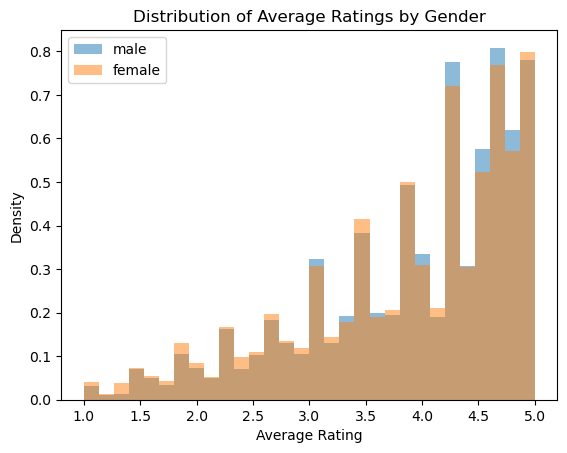

In [33]:
# ----- Q2: Gender difference in spread (variance/dispersion) of ratings -----

# Same split as Q1 (ok if you already defined these)
male_rating   = df_known_gender[df_known_gender["male"] == 1]["avg_rating"]
female_rating = df_known_gender[df_known_gender["female"] == 1]["avg_rating"]

male_n      = male_rating.size
female_n    = female_rating.size

# Spread measures
male_var = male_rating.var(ddof=1)
female_var = female_rating.var(ddof=1)
male_sd = male_rating.std(ddof=1)
female_sd = female_rating.std(ddof=1)

var_ratio = male_var / female_var  # >1 means male ratings more dispersed

# Levene's test for equality of variances (spread)
stat_levene, p_levene = stats.levene(
    male_rating,
    female_rating,
    center="mean"
)

alpha = 0.005

print("Q2: Is there a gender difference in the spread of the ratings distribution?\n")
print(f"Number of male profs:   {male_n}")
print(f"Number of female profs: {female_n}")
print(f"Variance (male):        {male_var:.4f}")
print(f"Variance (female):      {female_var:.4f}")
print(f"Std dev (male):         {male_sd:.4f}")
print(f"Std dev (female):       {female_sd:.4f}")
print(f"Variance ratio (male / female): {var_ratio:.3f}")
print(f"Levene test statistic:  {stat_levene:.3f}")
print(f"Levene p-value:         {p_levene:.3g}\n")

if p_levene < alpha:
    print(f"Conclusion (alpha = {alpha}):")
    print("  There IS a statistically significant gender difference "
          "in the spread (variance) of average ratings.")
else:
    print(f"Conclusion (alpha = {alpha}):")
    print("  There is NO statistically significant evidence of a gender "
          "difference in the spread of average ratings.")

# ---- Plot to visualize dispersion by gender ----
plt.figure()
plt.hist(male_rating, bins=30, alpha=0.5, density=True, label="male")
plt.hist(female_rating, bins=30, alpha=0.5, density=True, label="female")
plt.xlabel("Average Rating")
plt.ylabel("Density")
plt.title("Distribution of Average Ratings by Gender")
plt.legend()

**Question 3**

What is the likely size of both of these effects (gender bias in average rating, gender bias in spread of
average rating), as estimated from this dataset? Please use 95% confidence and make sure to report
each/both.

Q3: Effect sizes for gender differences in average ratings

95% CI for difference in MEAN rating (male - female):
  Difference in means: 0.054
  95% CI: [0.028, 0.080]

95% CI for difference in SPREAD (standard deviation, male - female):
  Difference in SDs: -0.039
  95% CI: [-0.057, -0.020]



Text(0.5, 1.0, 'Q3: 95% Confidence Intervals for Gender Effects')

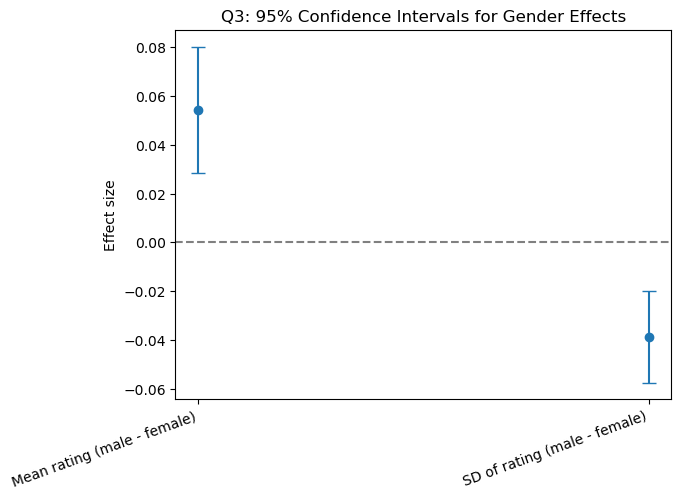

In [34]:
# ----- Q3: Size of gender effects (95% CIs for mean and spread) -----

# Recreate groups (ok if already defined earlier)
male_rating   = df_known_gender[df_known_gender["male"] == 1]["avg_rating"]
female_rating = df_known_gender[df_known_gender["female"] == 1]["avg_rating"]

male_mean   = male_rating.mean()
female_mean = female_rating.mean()
male_var    = male_rating.var(ddof=1)
female_var  = female_rating.var(ddof=1)
male_sd     = male_rating.std(ddof=1)
female_sd   = female_rating.std(ddof=1)
male_n      = male_rating.size
female_n    = female_rating.size

# ---------- 3a. 95% CI for difference in means (male - female) ----------

diff_mean = male_mean - female_mean
se_diff   = np.sqrt(male_var/male_n + female_var/female_n)

z = 1.96  # 95% CI
ci_mean_low  = diff_mean - z * se_diff
ci_mean_high = diff_mean + z * se_diff

print("Q3: Effect sizes for gender differences in average ratings\n")
print("95% CI for difference in MEAN rating (male - female):")
print(f"  Difference in means: {diff_mean:.3f}")
print(f"  95% CI: [{ci_mean_low:.3f}, {ci_mean_high:.3f}]\n")

# ---------- 3b. 95% CI for difference in spread (SD_male - SD_female) ----------

sd_diff = male_sd - female_sd

B = 5000  # number of bootstrap resamples
boot_sd_diff = []

for _ in range(B):
    boot_m = male_rating.sample(frac=1, replace=True)
    boot_f = female_rating.sample(frac=1, replace=True)
    boot_sd_diff.append(boot_m.std(ddof=1) - boot_f.std(ddof=1))

boot_sd_diff = np.array(boot_sd_diff)
ci_sd_low, ci_sd_high = np.percentile(boot_sd_diff, [2.5, 97.5])

print("95% CI for difference in SPREAD (standard deviation, male - female):")
print(f"  Difference in SDs: {sd_diff:.3f}")
print(f"  95% CI: [{ci_sd_low:.3f}, {ci_sd_high:.3f}]\n")

# ---------- 3c. Figure: effect sizes with 95% CIs ----------

effect_names = ["Mean rating (male - female)",
                "SD of rating (male - female)"]
effects = np.array([diff_mean, sd_diff])
ci_lows = np.array([ci_mean_low, ci_sd_low])
ci_highs = np.array([ci_mean_high, ci_sd_high])

# asymmetrical error bars
err_minus = effects - ci_lows
err_plus  = ci_highs - effects

x = np.arange(len(effects))

plt.figure()
plt.errorbar(x, effects, yerr=[err_minus, err_plus],
             fmt="o", capsize=5)
plt.axhline(0, color="gray", linestyle="--")
plt.xticks(x, effect_names, rotation=20, ha="right")
plt.ylabel("Effect size")
plt.title("Q3: 95% Confidence Intervals for Gender Effects")

**Question 4**

Is there a gender difference in the tags awarded by students? Make sure to teach each of the 20 tags
for a potential gender difference and report which of them exhibit a statistically significant different.
Comment on the 3 most gendered (lowest p-value) and least gendered (highest p-value) tags.

Q4: Gender differences in tag usage (normalized by number of ratings)

For each tag, we compare the average tag rate per rating between male
and female professors using a Welch two-sample t-test.

Number of tags tested: 20
Number of tags significant at alpha = 0.005: 18

Three MOST gendered tags (smallest p-values):
  Tag: hilarious
    male mean rate:   0.1541
    female mean rate: 0.0899
    diff (male - female): 0.0641
    p-value: 9.32e-141

  Tag: amazing_lectures
    male mean rate:   0.1284
    female mean rate: 0.0999
    diff (male - female): 0.0285
    p-value: 2.71e-38

  Tag: caring
    male mean rate:   0.1928
    female mean rate: 0.2264
    diff (male - female): -0.0335
    p-value: 8.86e-34

Three LEAST gendered tags (largest p-values):
  Tag: pop_quizzes
    male mean rate:   0.0357
    female mean rate: 0.0344
    diff (male - female): 0.0013
    p-value: 0.364

  Tag: accessible
    male mean rate:   0.0695
    female mean rate: 0.0653
    diff (male - female): 0.004

Text(0.5, 1.0, 'Q4: Gender Differences in Tag Usage (per Rating)')

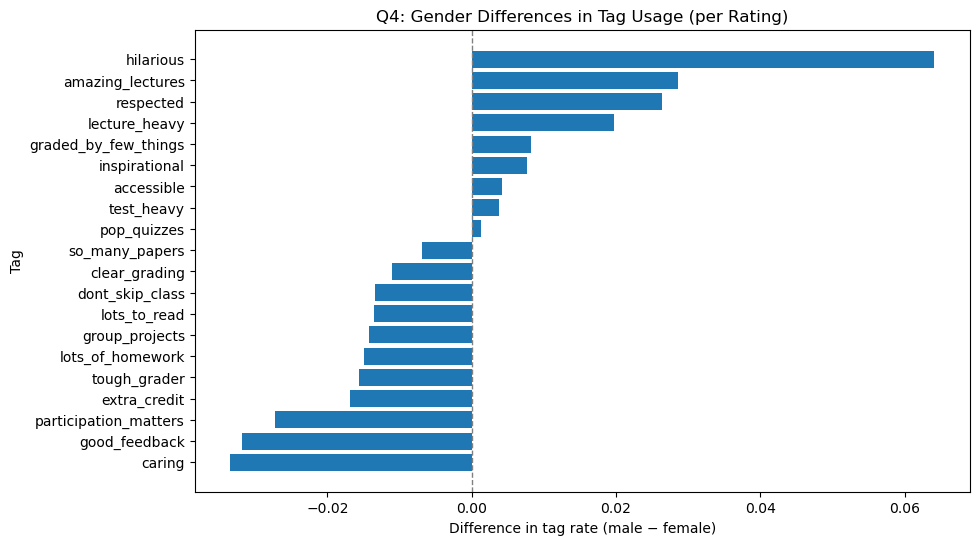

In [35]:
# ----- Q4: Gender differences in tags (normalized per rating) -----

alpha = 0.005

# Pre-split rows by gender once
male_rows   = df_known_gender[df_known_gender["male"] == 1]
female_rows = df_known_gender[df_known_gender["female"] == 1]

results = []

for tag in tag_names:
    # Tag rate per rating (NOT stored in df; computed on the fly)
    male_rate   = male_rows[tag] / male_rows["n_ratings"]
    female_rate = female_rows[tag] / female_rows["n_ratings"]

    # Drop any NaNs just in case
    male_rate   = male_rate.dropna()
    female_rate = female_rate.dropna()

    m_mean = male_rate.mean()
    f_mean = female_rate.mean()

    # Welch t-test on tag rates
    t_stat, p_two = stats.ttest_ind(
        male_rate, female_rate,
        equal_var=False,
        nan_policy="omit"
    )

    results.append({
        "tag": tag,
        "male_mean_rate": m_mean,
        "female_mean_rate": f_mean,
        "diff_mean_rate": m_mean - f_mean,  # positive => higher for males
        "t_stat": t_stat,
        "p_value": p_two
    })

tag_results = pd.DataFrame(results)
tag_results["significant"] = tag_results["p_value"] < alpha

# ---- Print overall summary ----
print("Q4: Gender differences in tag usage (normalized by number of ratings)\n")
print("For each tag, we compare the average tag rate per rating between male")
print("and female professors using a Welch two-sample t-test.\n")

print(f"Number of tags tested: {len(tag_names)}")
print(f"Number of tags significant at alpha = {alpha}: "
      f"{int(tag_results['significant'].sum())}\n")

# ---- 3 most gendered tags (smallest p-values) ----
most_gendered = tag_results.sort_values("p_value").head(3)

print("Three MOST gendered tags (smallest p-values):")
for _, row in most_gendered.iterrows():
    print(f"  Tag: {row['tag']}")
    print(f"    male mean rate:   {row['male_mean_rate']:.4f}")
    print(f"    female mean rate: {row['female_mean_rate']:.4f}")
    print(f"    diff (male - female): {row['diff_mean_rate']:.4f}")
    print(f"    p-value: {row['p_value']:.3g}")
    print()

# ---- 3 least gendered tags (largest p-values) ----
least_gendered = tag_results.sort_values("p_value", ascending=False).head(3)

print("Three LEAST gendered tags (largest p-values):")
for _, row in least_gendered.iterrows():
    print(f"  Tag: {row['tag']}")
    print(f"    male mean rate:   {row['male_mean_rate']:.4f}")
    print(f"    female mean rate: {row['female_mean_rate']:.4f}")
    print(f"    diff (male - female): {row['diff_mean_rate']:.4f}")
    print(f"    p-value: {row['p_value']:.3g}")
    print()

# ---- Plot: difference in tag rates by gender ----
plt.figure(figsize=(10, 6))

ordered = tag_results.sort_values("diff_mean_rate")["tag"]

plt.barh(
    ordered,
    tag_results.set_index("tag").loc[ordered, "diff_mean_rate"]
)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Difference in tag rate (male − female)")
plt.ylabel("Tag")
plt.title("Q4: Gender Differences in Tag Usage (per Rating)")